<img src="../assets/header.gif" style="width:100%">
<hr style="color:#808080;">
<p align="center"><b>S H A G G Y &mdash; B U I L D I N G   T H E   G R A P H S</b></p>
<hr style="color:#808080;">

A demonstration of `shaggy.models.tools.build_mesh`, the function that builds the
hierarchical mesh consumed by `GraphAE` (`shaggy.models.gae`). Meshes are built once
and reused (they don't depend on model weights), so this notebook is separate from
`demo-models.ipynb`: build here, save to disk, load there.

Steps: load the Black Sea data and combine per-channel masks into one shared domain
&rarr; build the mesh and look at how it coarsens across hierarchy levels &rarr; save
it to disk under a descriptive filename &rarr; show how `axis_scale` generalizes mesh
construction to a 3rd (e.g. depth) axis, on a small synthetic grid.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

from pathlib import Path

from shaggy.models.tools import build_mesh

# This machine exposes a lot of CPU cores (shared HPC node); torch's default of
# spawning that many threads for tiny per-node tensor ops is pure overhead here
# and makes the graph ops ~100x slower than they need to be. A handful is plenty.
torch.set_num_threads(4)


<hr style="color:#808080;">
<p align="center"><b>D A T A   &amp;   D O M A I N   M A S K</b></p>
<hr style="color:#808080;">


In [2]:
x = torch.load("data/x.pt")     # (N, C, Y, X), NaN on land
mask = torch.load("data/mask.pt")  # (C, Y, X), 1 = sea, 0 = land, one mask per channel

N, C, Y, X = x.shape
print(f"x    : {tuple(x.shape)}  ({N} samples, {C} channels, {Y}x{X} grid)")
print(f"mask : {tuple(mask.shape)}")
print(f"sea cells per channel: {[int(m.sum()) for m in mask.bool()]}")


x    : (16, 8, 128, 256)  (16 samples, 8 channels, 128x256 grid)
mask : (8, 128, 256)
sea cells per channel: [19172, 19035, 18186, 14213, 19172, 19035, 18186, 14213]


sea cells (union of all 8 channels): 19172 / 32768 (58.5%)


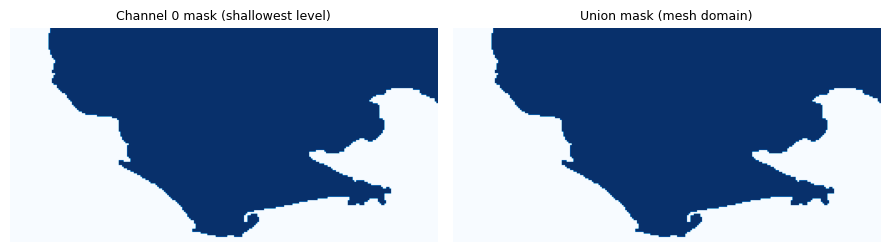

channel 0 mask == union mask: True


In [3]:
# GraphAE needs one shared node set: every channel's feature vector lives on the same
# mesh, so the same set of grid cells has to be "nodes" for all of them. But sea/land
# coverage varies by channel here (temperature/oxygen at 4 depths each; deeper levels
# exclude more coastal cells) — so which mask do we build the mesh from?
#
# The union: a cell becomes a node if it's sea in *at least one* channel. A channel
# that's land there just gets a 0 value at that node, which shaggy.loss.AELoss already
# weights out of the loss (see demo-models.ipynb) — no different from any other land
# cell. Building from the union (rather than, say, the intersection) keeps every
# channel's true sea cells as nodes, so nothing real gets thrown away.
domain_mask = mask.bool().any(dim=0)

sea_frac = domain_mask.float().mean().item()
print(f"sea cells (union of all {C} channels): {domain_mask.sum().item()} / {domain_mask.numel()} ({100 * sea_frac:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(mask[0].numpy(), cmap="Blues")
axes[0].set_title("Channel 0 mask (shallowest level)", fontsize=9)
axes[1].imshow(domain_mask.numpy(), cmap="Blues")
axes[1].set_title("Union mask (mesh domain)", fontsize=9)
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

# Here they're identical: depth exclusion is strictly nested (a cell missing at a
# shallow level is missing at every deeper one too), so the shallowest channel's mask
# already is the union. That won't generally hold — e.g. the (C, X, Y, Z) case further
# down, where C indexes independent variables rather than nested depths.
print(f"channel 0 mask == union mask: {torch.equal(mask[0].bool(), domain_mask)}")


<hr style="color:#808080;">
<p align="center"><b>B U I L D I N G   T H E   M E S H</b></p>
<hr style="color:#808080;">


In [8]:
NUM_LEVELS, REDUCTION, K, ITERATIONS, SEED = 5, 2, 32, 16, 2107

mesh = build_mesh(
    resolution=(Y, X),
    num_levels=NUM_LEVELS,
    reduction=REDUCTION,
    k=K,
    iterations=ITERATIONS,
    mask=domain_mask,
    seed=SEED,
)

for level, pos in enumerate(mesh.pos):
    tag = "grid (sea cells)" if level == 0 else f"mesh level {level}"
    print(f"Level {level} ({tag:<16}): {pos.shape[0]:6d} nodes, {mesh.edges[level].shape[1]:6d} intra-level edges")


Level 0 (grid (sea cells)):  19172 nodes,      0 intra-level edges
Level 1 (mesh level 1    ):   9586 nodes, 326620 intra-level edges
Level 2 (mesh level 2    ):   4793 nodes, 165992 intra-level edges
Level 3 (mesh level 3    ):   2396 nodes,  83710 intra-level edges
Level 4 (mesh level 4    ):   1198 nodes,  42222 intra-level edges
Level 5 (mesh level 5    ):    599 nodes,  21524 intra-level edges


<hr style="color:#808080;">
<p align="center"><b>M E S H   A C R O S S   H I E R A R C H Y   L E V E L S</b></p>
<hr style="color:#808080;">

Each level's nodes plotted directly over the domain, to see how the K-means hierarchy
follows the Black Sea's coastline — denser where it's irregular, coarser offshore.
Level 0 has one node per sea pixel, so it's shown as the mask itself.


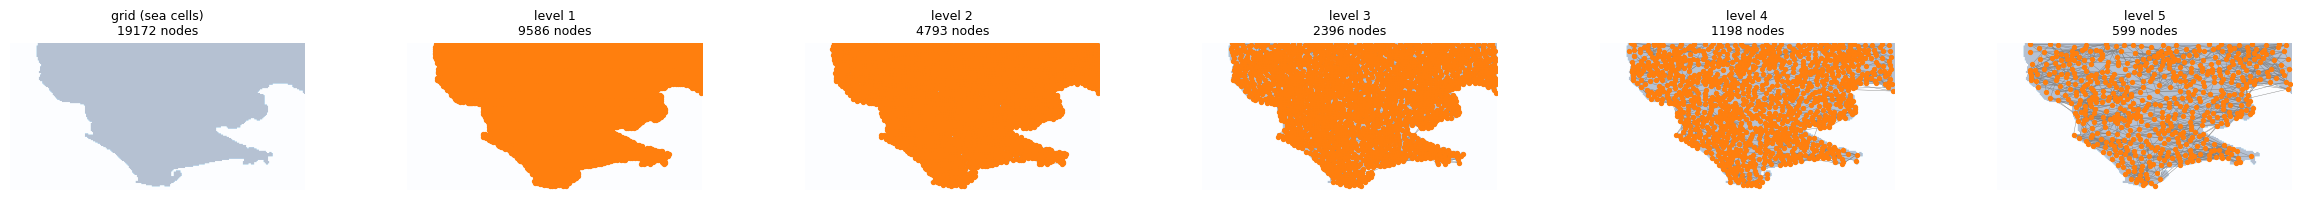

In [9]:
def mesh_panel(ax, level, pos, edges, domain_mask, title, max_edges=2000):
    r'''Draws one mesh level's nodes/edges over the domain mask onto a given axis.'''
    L1, L2 = domain_mask.shape

    ax.imshow(domain_mask.numpy(), cmap="Blues", alpha=0.3)
    ax.axis("off")
    ax.set_title(title, fontsize=9)

    if level == 0:
        return  # one node per sea pixel: the mask above already shows them all

    rows, cols = pos[:, 0].numpy() * (L1 - 1), pos[:, 1].numpy() * (L2 - 1)

    e = edges
    if e.shape[1] > max_edges:
        idx = torch.randperm(e.shape[1])[:max_edges]
        e = e[:, idx]
    for src, dst in e.T:
        ax.plot([cols[src], cols[dst]], [rows[src], rows[dst]], color="gray", linewidth=0.3, zorder=1)

    ax.scatter(cols, rows, s=8, zorder=2, color="C1")


def plot_mesh_levels(mesh, domain_mask):
    r'''Plots every mesh level's nodes/edges over the domain, side by side.'''
    L = len(mesh.pos)
    fig, axes = plt.subplots(1, L, figsize=(4 * L, 4 * domain_mask.shape[0] / domain_mask.shape[1]))

    for level, (ax, pos, edges) in enumerate(zip(axes, mesh.pos, mesh.edges)):
        tag = "grid (sea cells)" if level == 0 else f"level {level}"
        mesh_panel(ax, level, pos, edges, domain_mask, f"{tag}\n{pos.shape[0]} nodes")

    plt.tight_layout()
    plt.show()


plot_mesh_levels(mesh, domain_mask)


<hr style="color:#808080;">
<p align="center"><b>S A V I N G   &amp;   R E U S I N G   T H E   M E S H</b></p>
<hr style="color:#808080;">

The mesh only depends on the domain and the build parameters above, not on any
trained model, so it's worth building once and reusing — `demo-models.ipynb` loads
the exact file saved here rather than rebuilding it. The filename spells out how it
was built, so a differently-configured mesh never gets silently reused by mistake.


In [10]:
mesh_path = Path(f"data/mesh_L{Y}x{X}_r{REDUCTION}_k{K}_lvl{NUM_LEVELS}_seed{SEED}.pt")

torch.save(mesh, mesh_path)
print(f"Saved mesh to {mesh_path} ({mesh_path.stat().st_size / 1e6:.2f} MB)")

mesh_reloaded = torch.load(mesh_path, weights_only=False)
matches = all(torch.equal(a, b) for a, b in zip(mesh.pos, mesh_reloaded.pos))
print(f"Reloaded mesh matches the original: {matches}")


Saved mesh to data/mesh_L128x256_r2_k32_lvl5_seed2107.pt (11.77 MB)
Reloaded mesh matches the original: True


<hr style="color:#808080;">
<p align="center"><b>G E N E R A L I Z I N G   B E Y O N D   2 D  :   <code>axis_scale</code></b></p>
<hr style="color:#808080;">

`build_mesh` already takes an arbitrary `resolution = (L_1, ..., L_N)`, so a future
state shaped `(C, X, Y, Z)` needs no code change to build a mesh over `(X, Y, Z)`. The
open question was how to control neighbor density *per axis* — e.g. weighting a coarser
Z axis differently than X/Y.

A literal "k neighbors along Z" doesn't have a natural meaning here: K-means/k-NN work
on an unstructured, possibly-masked point cloud (that's the whole point of using a mesh
instead of a regular conv — see `.claude/shaggy-python.md` KISS + the ocean's irregular
coastline), not a structured grid where "along Z" is a well-defined direction with a
fixed neighbor count. `axis_scale` gives an equivalent, continuous control instead: it
rescales node coordinates *only for the distance computation* used by K-means/k-NN (not
the coordinates themselves, which stay in true `[0, 1]` grid space for plotting/features).

Scaling an axis **up** makes it dominate the distance, so K-means/k-NN mainly select
for closeness along *that* axis (tight packing along it, looser along the others).
Scaling it **down** makes it count for less, so neighbors are chosen almost freely
along it (wider reach/spread along that axis) in exchange for tighter packing along
the others. Demonstrated both ways below on a synthetic `(16, 16, 8)` toy grid, since
the real data has no 3rd spatial axis yet.


In [ ]:
RESOLUTION_3D = (16, 16, 8)  # stand-in for a future (X, Y, Z) state
MESH_KWARGS_3D = dict(resolution=RESOLUTION_3D, num_levels=1, reduction=4, k=6, iterations=8, seed=0)

meshes = {
    "isotropic (axis_scale=None)": build_mesh(**MESH_KWARGS_3D),
    "Z tight (axis_scale=(1, 1, 3.0))": build_mesh(**MESH_KWARGS_3D, axis_scale=(1.0, 1.0, 3.0)),
    "Z loose (axis_scale=(1, 1, 0.3))": build_mesh(**MESH_KWARGS_3D, axis_scale=(1.0, 1.0, 0.3)),
}


def mean_abs_edge_displacement(mesh, level=1):
    r'''Mean absolute per-axis displacement between every intra-level edge's endpoints.'''
    pos, edges = mesh.pos[level], mesh.edges[level]
    src, dst = edges
    return (pos[src] - pos[dst]).abs().mean(dim=0)


displacements = {name: mean_abs_edge_displacement(mesh) for name, mesh in meshes.items()}

print(f"{'':<34}{'X':>8}{'Y':>8}{'Z':>8}")
for name, disp in displacements.items():
    print(f"{name:<34}{disp[0].item():>8.4f}{disp[1].item():>8.4f}{disp[2].item():>8.4f}")


In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))

names = list(meshes.keys())
xpos, width = np.arange(3), 0.8 / len(names)

for i, name in enumerate(names):
    ax.bar(xpos + (i - 1) * width, displacements[name].numpy(), width, label=name)

ax.set_xticks(xpos)
ax.set_xticklabels(["X", "Y", "Z"])
ax.set_ylabel("Mean |Δ| between connected mesh nodes")
ax.set_title("Effect of axis_scale on mesh connectivity")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Z tight (scale > 1): mean Z displacement shrinks below isotropic — neighbors are
# chosen for Z-closeness, at the cost of looser X/Y packing.
# Z loose (scale < 1): the opposite — Z stops constraining neighbor choice, so
# selected neighbors reach much further apart in Z, while X/Y packing tightens.
